# **Healthcare Insurance Cost Analysis - Data Visualisation**

## Objectives

The objective of this notebook is to use the cleaned healthcare insurance dataset to explore how personal, lifestyle and geographic factors are related to insurance charges.

This notebook will:

* Load the cleaned insurance dataset created in the ETL notebook
* Explore relationships between insurance charges and variables such as age, BMI, smoking status, sex, children and region
* Create visualisations to support the analysis
* Summarise the key findings and possible next steps

## Inputs

The input for this notebook is the cleaned dataset:

* `outputs/cleaned_insurance.csv`

## Outputs

The outputs of this notebook will include:

* Exploratory data analysis tables
* Visualisations showing patterns in insurance charges
* Written insights explaining which factors appear to be most strongly related to insurance charges
* A final summary of key findings, limitations and next steps

---
# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory.

We need to change the working directory from its current folder to its parent folder.

* We access the current directory with `os.getcwd()`

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/sahraosman/Documents/vscode-projects/Healthcare_Insurance/jupyter_notebooks'

We want to make the parent of the current directory the new current directory.

* `os.path.dirname()` gets the parent directory
* `os.chdir()` defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/sahraosman/Documents/vscode-projects/Healthcare_Insurance'

---
# Section 1: Load Cleaned Dataset

In this section, the cleaned healthcare insurance dataset created in the ETL notebook is loaded for exploratory data analysis and visualisation.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("outputs/cleaned_insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.shape

(1337, 7)

The cleaned dataset has loaded successfully. This dataset contains 1,337 rows and 7 columns after the duplicate row was removed in the ETL notebook.

# Section 2: Exploratory Data Analysis

This section explores the relationships between insurance charges and the other variables in the dataset. Summary statistics and grouped analysis will be used to identify early patterns before creating visualisations.

## Target Variable: Charges

In [6]:
df['charges'].describe().round(2)

count     1337.00
mean     13279.12
std      12110.36
min       1121.87
25%       4746.34
50%       9386.16
75%      16657.72
max      63770.43
Name: charges, dtype: float64

This shows the characteristics of the `charges` column, which is the target variable for this analysis. The mean insurance charge is approximately 13,279.12, with a standard deviation of 12,110.36. The minimum charge is 1,121.87, while the maximum charge is 63,770.43. The median charge is 9,386.16, indicating that half of the customers have charges below this amount and half have charges above it. The mean is higher than the median, which suggests that the distribution of insurance charges is right-skewed, with a few customers having very high charges.

## Categorical and Count Variable Distributions

In [7]:
df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

There are 662 female customers and 675 male customers in the dataset, indicating a fairly balanced gender distribution. This means both groups are well represented, making it reasonable to compare insurance charges by sex later in the analysis.

In [8]:
df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

There are more non-smokers (1,063) than smokers (274) in the dataset. This shows that smoking status is imbalanced, with non-smokers making up most of the records. This should be considered when comparing insurance charges by smoking status later in the analysis.

In [9]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

The regional distribution is fairly balanced. The southeast has the highest number of customers with 364 records, while the other regions have similar counts: 325 from the southwest, 324 from the northwest, and 324 from the northeast. This means all regions are well represented, making it reasonable to compare insurance charges by region later in the analysis.

In [10]:
df['children'].value_counts().sort_index()

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

This shows the number of children covered by insurance for each customer. The majority of customers (573) have no children, while 324 customers have one child, 240 have two children, 157 have three children, 25 have four children, and 18 have five children. This shows that customers with no children are the largest group, while customers with four or five children are much less common.

## Numerical Variable Distributions

In [11]:
df[['age', 'bmi']].describe().round(2)

,age,bmi
count,1337.00,1337.00
mean,39.22,30.66
std,14.04,6.10
min,18.00,15.96
25%,27.00,26.29
50%,39.00,30.40
75%,51.00,34.70
max,64.00,53.13


For age and BMI, the summary statistics show that the average age of customers is approximately 39 years, with a minimum age of 18 and a maximum age of 64. The average BMI is approximately 30.66, with a minimum BMI of 15.96 and a maximum BMI of 53.13. The median age is 39, which is very close to the mean, suggesting the age distribution is fairly balanced. The median BMI is 30.40, which is also close to the mean BMI of 30.66. This suggests that the BMI distribution is not heavily skewed, although the maximum BMI of 53.13 shows that some customers have much higher BMI values.

## Average Insurance Charges by Group

In [12]:
df.groupby('smoker')['charges'].mean().round(2)

smoker
no      8440.66
yes    32050.23
Name: charges, dtype: float64

This shows that non-smokers have an average insurance charge of approximately 8,440.66, while smokers have a much higher average charge of approximately 32,050.23. This suggests that smoking status appears to have a strong relationship with insurance charges, with smokers having significantly higher average costs than non-smokers.

In [13]:
df.groupby('sex')['charges'].mean().round(2)

sex
female    12569.58
male      13975.00
Name: charges, dtype: float64

This shows that females have an average insurance charge of approximately 12,569.58, while males have a slightly higher average charge of approximately 13,975.00. This suggests that there is a small difference in average insurance charges by sex, with males having slightly higher average costs than females.

In [14]:
df.groupby('children')['charges'].mean().round(2)

children
0    12384.70
1    12731.17
2    15073.56
3    15355.32
4    13850.66
5     8786.04
Name: charges, dtype: float64

Customers with no children have an average insurance charge of approximately 12,384.70, while customers with one child have a slightly higher average charge of approximately 12,731.17. Customers with two and three children have higher average charges, at approximately 15,073.56 and 15,355.32. Customers with four children have an average charge of approximately 13,850.66, while customers with five children have the lowest average charge of approximately 8,786.04.

This suggests that the number of children does not show a simple pattern where charges increase steadily as the number of children increases. The lower average charge for customers with five children may be affected by the small sample size, as there are only 18 customers in that group. Therefore, this result should be interpreted with caution.

In [15]:
df.groupby('region')['charges'].mean().round(2)

region
northeast    13406.38
northwest    12450.84
southeast    14735.41
southwest    12346.94
Name: charges, dtype: float64

The region with the highest average insurance charges is the southeast, with an average charge of approximately 14,735.41. The region with the lowest average insurance charges is the southwest, with an average charge of approximately 12,346.94.

The northwest and southwest regions have very similar average charges, while the northeast is slightly higher at approximately 13,406.38. This suggests that there may be some regional differences in insurance charges, especially between the southeast and the other regions. However, the regional differences are much smaller than the difference seen between smokers and non-smokers, so region appears to have a weaker relationship with charges than smoking status.

## Section 2 Summary

The exploratory analysis shows that smoking status appears to have the strongest relationship with insurance charges so far, as smokers have much higher average charges than non-smokers. Sex, region and number of children show some differences in average charges, but these differences are smaller and less consistent than the difference between smokers and non-smokers.

The number of children does not show a simple pattern where charges increase steadily, and the result for customers with five children should be interpreted carefully due to the small sample size. The next section will use visualisations to explore these patterns more clearly.

---

# Section 3: Data Visualisation

This section will use visualisations to explore the relationships between insurance charges and the other variables in the dataset. Visualisations can help identify patterns and trends that may not be immediately apparent from summary statistics alone.

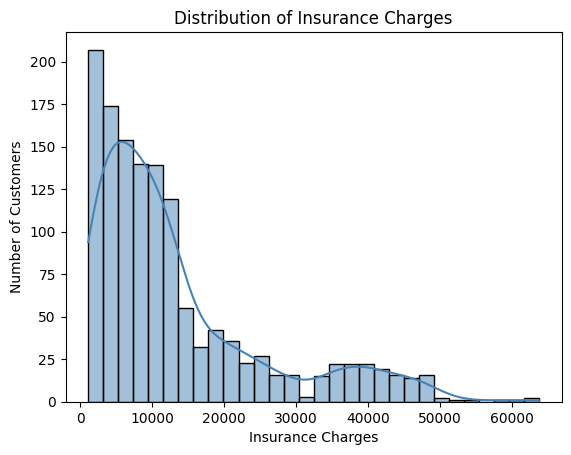

In [16]:
sns.histplot(data=df, x='charges', bins=30, kde=True,
			 color='steelblue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Insurance Charges')
plt.ylabel('Number of Customers')
plt.show()

The histogram shows that insurance charges are right-skewed. Most customers have lower insurance charges, while fewer customers have very high charges. This supports the earlier summary statistics, where the mean charge was higher than the median charge.

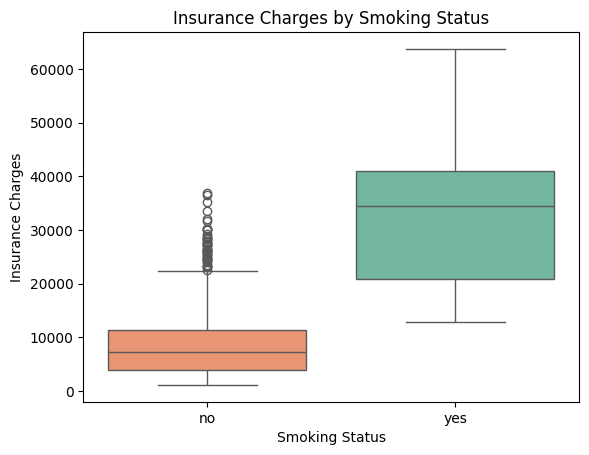

In [17]:
sns.boxplot(data=df, x='smoker', y='charges', hue='smoker', order=['no', 'yes'], palette='Set2', legend=False)
plt.title('Insurance Charges by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Insurance Charges')
plt.show()

The boxplot shows a clear difference in insurance charges between smokers and non-smokers. Smokers generally have much higher charges, with a higher median and a wider spread of values. Non-smokers mostly have lower charges, although there are some high-charge outliers. This supports the earlier grouped analysis, where smokers had a much higher average insurance charge than non-smokers.

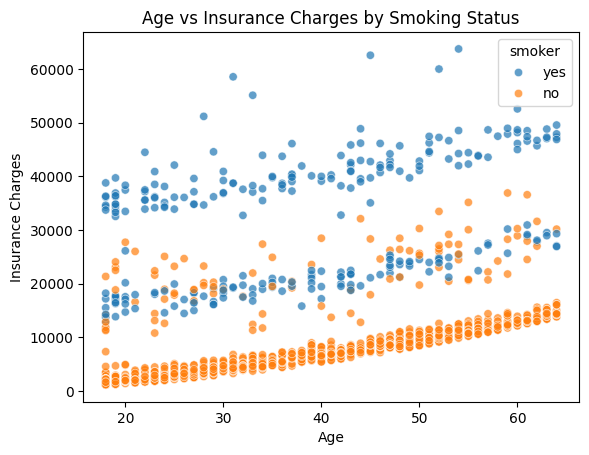

In [18]:
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7)
plt.title('Age vs Insurance Charges by Smoking Status')
plt.xlabel('Age')
plt.ylabel('Insurance Charges')
plt.show()

This scatter plot shows that insurance charges generally increase with age. However, smoking status creates a clear separation between customers, as smokers tend to have much higher charges than non-smokers across most age groups. This suggests that age is related to insurance charges, but smoking status appears to have a stronger relationship with the level of charges.

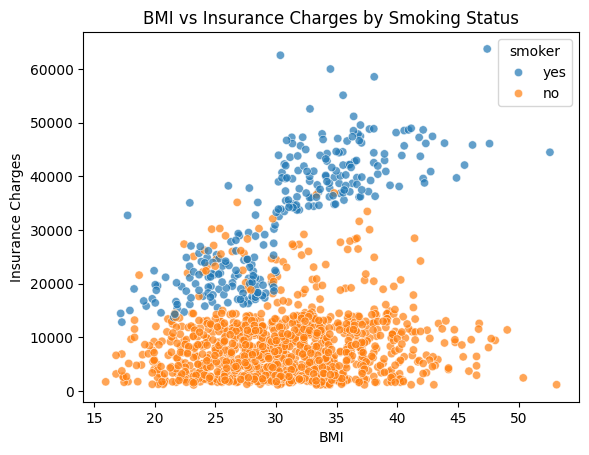

In [19]:
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.7)
plt.title('BMI vs Insurance Charges by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Insurance Charges')
plt.show()

The scatter plot shows a weaker positive relationship between BMI and insurance charges compared with the age scatter plot. Higher BMI values appear to be associated with higher charges, especially among smokers. Non-smokers mostly remain in the lower charge range, while smokers are more commonly found in the higher charge range. This suggests that BMI may have some relationship with insurance charges, but smoking status appears to have a stronger relationship with charges.

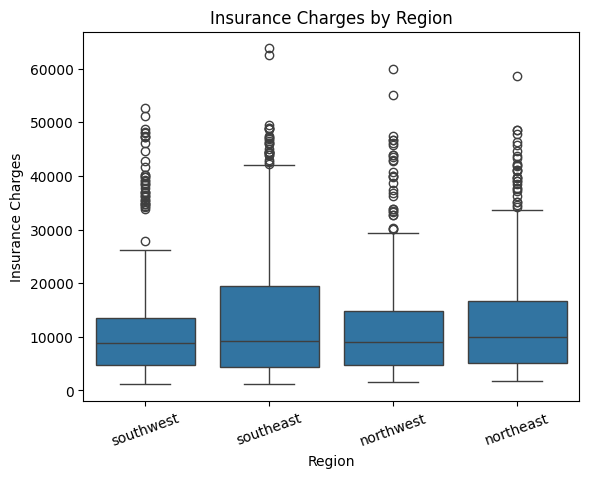

In [20]:
sns.boxplot(data=df, x='region', y='charges')
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Insurance Charges')
plt.xticks(rotation=20)
plt.show()

The boxplot shows that insurance charges vary across regions, but the differences are not as large as the difference between smokers and non-smokers. The southeast region appears to have a wider spread of charges and higher upper values compared with some other regions. However, the median charges across regions are relatively similar, suggesting that region has a weaker relationship with insurance charges than smoking status.

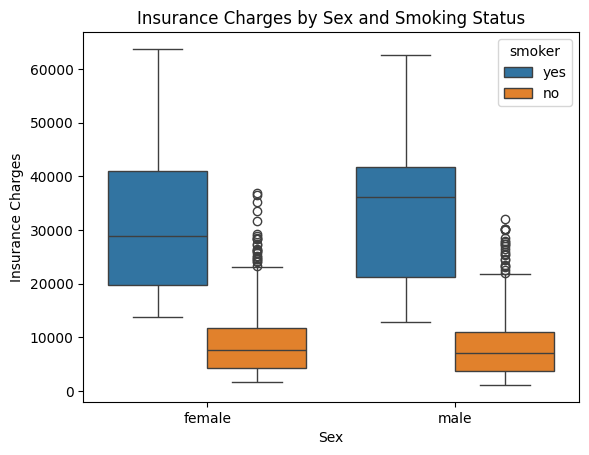

In [21]:
sns.boxplot(data=df, x='sex', y='charges', hue='smoker')
plt.title('Insurance Charges by Sex and Smoking Status')
plt.xlabel('Sex')
plt.ylabel('Insurance Charges')
plt.show()

The boxplot shows that smokers have higher insurance charges than non-smokers for both females and males. The difference between smokers and non-smokers is much larger than the difference between females and males. This suggests that sex has a weaker relationship with insurance charges than smoking status.

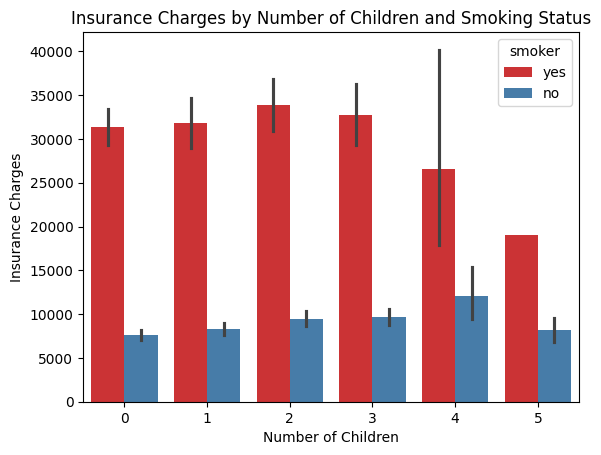

In [22]:
sns.barplot(data=df, x='children', y='charges', hue='smoker', palette='Set1')
plt.title('Insurance Charges by Number of Children and Smoking Status')
plt.xlabel('Number of Children')
plt.ylabel('Insurance Charges')
plt.show()


The bar chart shows that smokers have higher average insurance charges than non-smokers across every number of children group. The number of children does not show a clear pattern where charges increase steadily as the number of children increases. Smoking status appears to have a much stronger relationship with insurance charges than the number of children. The larger error bars for some groups suggest that these results should be interpreted carefully, especially where there may be fewer customers.

## Section 3 Summary

The visualisations support the findings from the exploratory data analysis. Insurance charges are right-skewed, with most customers having lower charges and fewer customers having very high charges. Smoking status shows the clearest difference in charges, with smokers consistently having much higher insurance costs than non-smokers.

Age and BMI both show some relationship with charges, but smoking status creates a stronger separation between high and low charges. Region, sex and number of children show some variation, but their relationships with insurance charges appear weaker and less consistent than smoking status.

---

# Final Conclusion

This analysis shows that smoking status has the strongest relationship with insurance charges in this dataset. Smokers consistently have much higher charges than non-smokers across different groups.

Age and BMI also appear to have positive relationships with insurance charges, although these relationships are weaker than smoking status. Region, sex and number of children show some variation, but their relationships with charges appear weaker and less consistent.

Overall, the visualisations suggest that lifestyle factors, especially smoking, are more strongly associated with higher insurance charges than geographic or demographic factors in this dataset.

## Limitations

This analysis is based on one dataset, so the findings may not represent all healthcare insurance customers or all healthcare systems. The dataset also does not include other factors that could affect medical costs, such as medical history, income, occupation, exercise habits or pre-existing conditions.

The analysis shows relationships between variables and insurance charges, but it does not prove direct causation. Some groups, such as customers with four or five children, also have smaller sample sizes, so their averages should be interpreted carefully.

## Next Steps

Future analysis could include building a simple predictive model to estimate insurance charges based on customer characteristics. Additional variables such as medical history or lifestyle data could make the analysis more complete. Further work could also compare different modelling approaches and evaluate which variables are most useful for prediction.